<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:


Saving meuse.txt to meuse (6).txt

[INFO] Total data valid dimuat: 155 baris observasi.

--- STATISTIK DESKRIPTIF SEMUA VARIABEL ---
              zinc      copper        lead     cadmium
count   155.000000  155.000000  155.000000  155.000000
mean    469.716129   40.316129  153.361290    3.245806
std     367.073788   23.680436  111.320054    3.523746
min     113.000000   14.000000   37.000000    0.200000
25%     198.000000   23.000000   72.500000    0.800000
50%     326.000000   31.000000  123.000000    2.100000
75%     674.500000   49.500000  207.000000    3.850000
max    1839.000000  128.000000  654.000000   18.100000


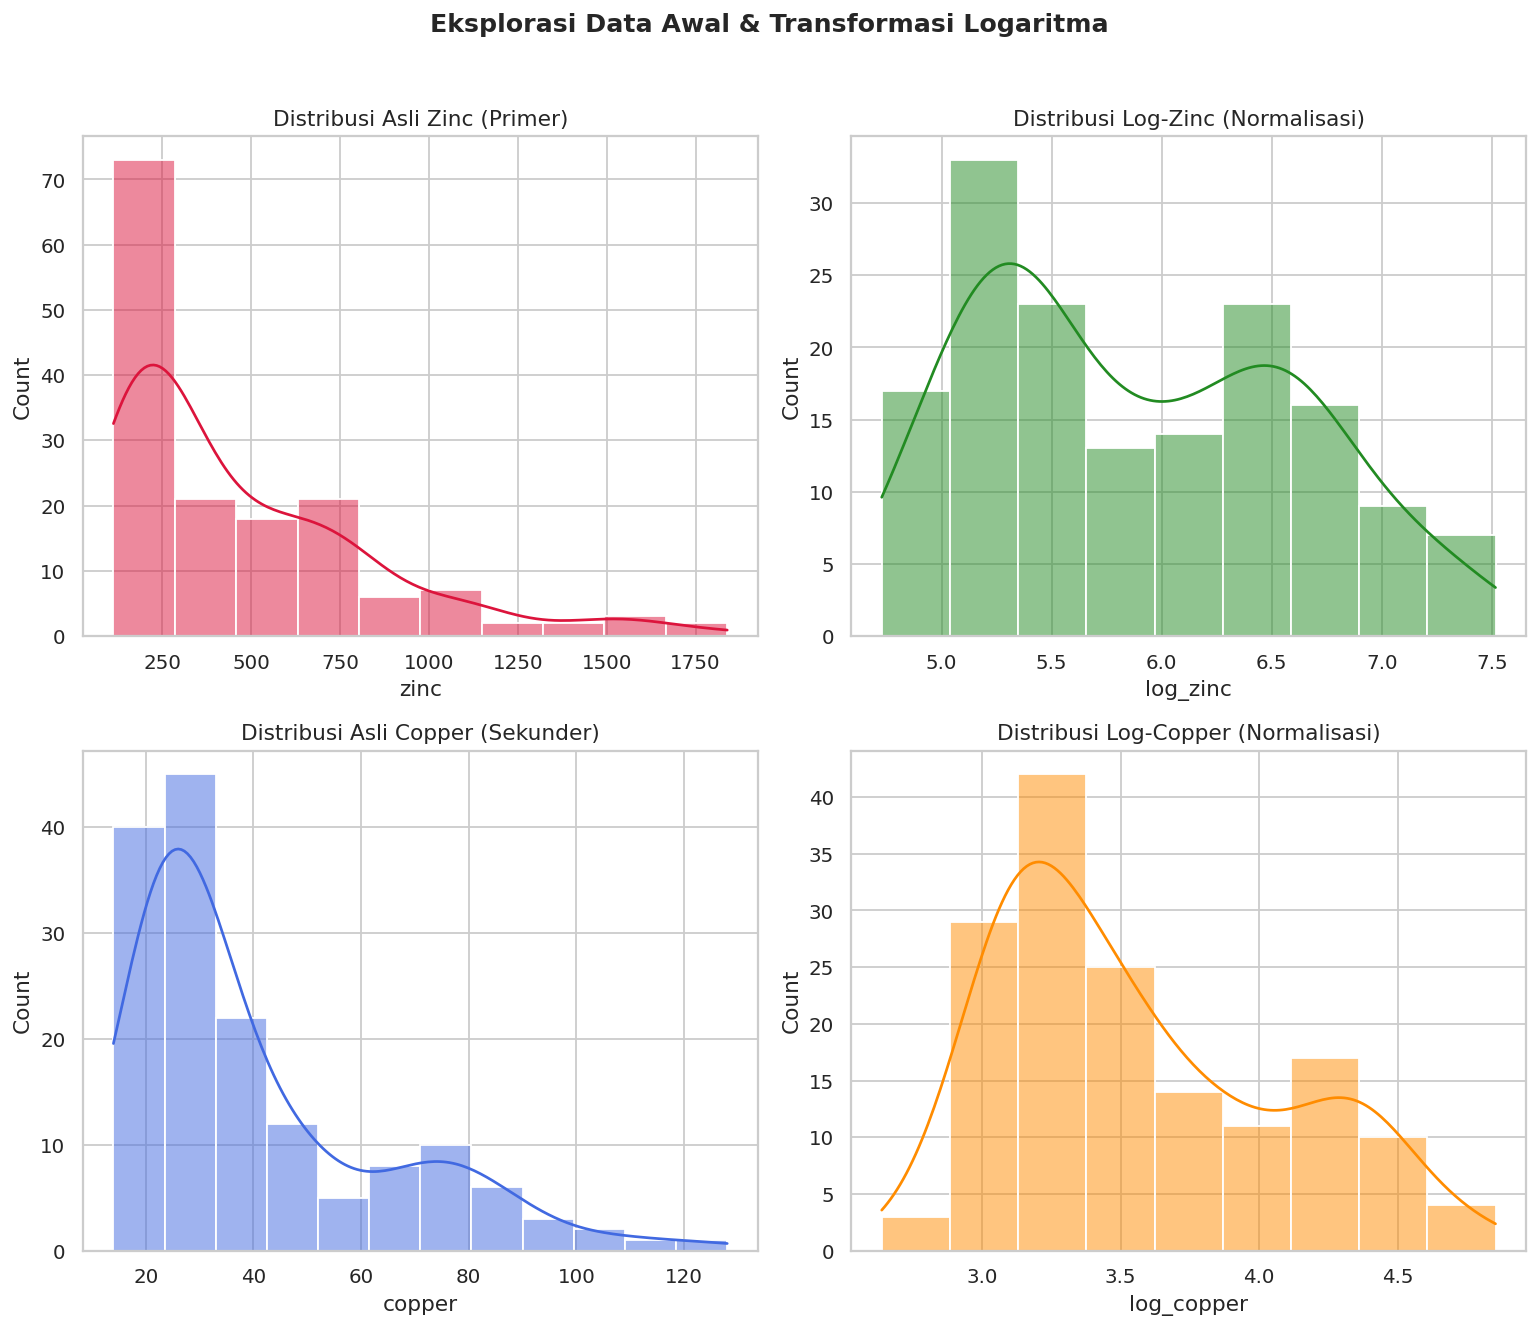


 TABEL 3.1: PARAMETER HASIL FITTING MODEL VARIOGRAM LMC
  Model LMC  Nugget Primer (c0)  Sill Total Primer (c0+c)  Range (a)    Nilai SSE
Exponential            0.061098                  0.580955 740.127383 1.000000e+09
  Spherical            0.036348                  0.542585 740.127392 7.744215e-01
   Gaussian            0.061921                  0.579544 740.127378 1.000000e+09

[INFO] Model LMC terbaik terpilih berdasarkan SSE terkecil: Spherical


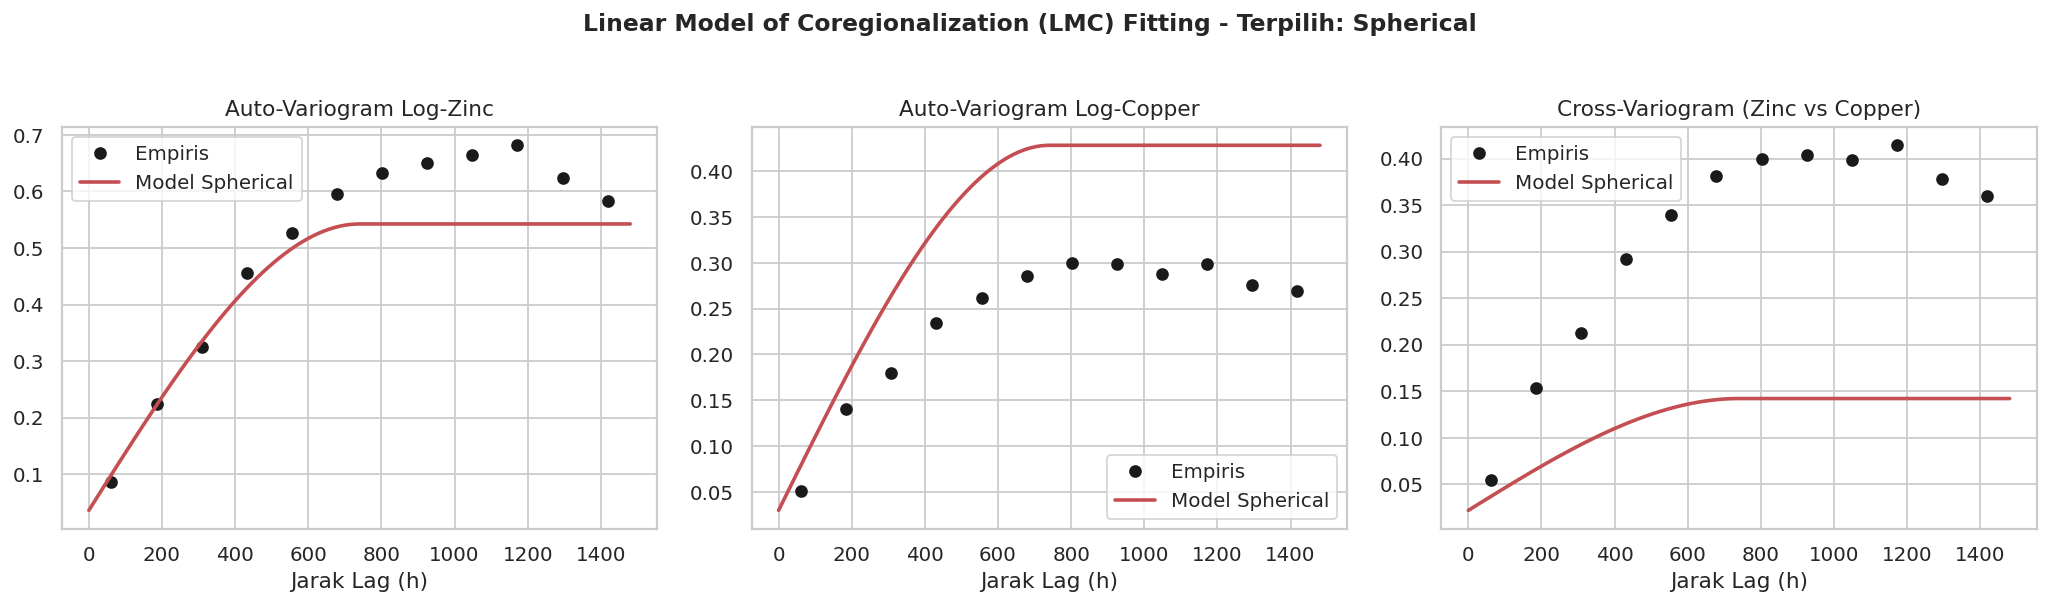


[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV) Co-Kriging...

 HASIL EVALUASI VALIDASI SILANG ORDINARY CO-KRIGING
 RMSE (Skala Log) : 0.3907
 MAE (Skala Log)  : 0.2884
 Koefisien (R²)   : 0.7052


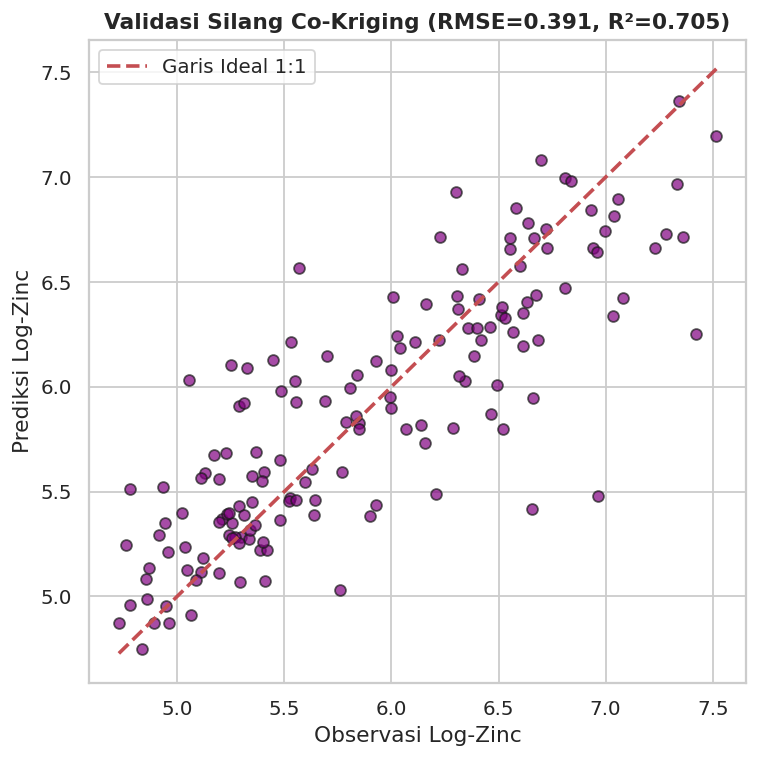


[INFO] Membangun Grid Peta Interpolasi Spasial Co-Kriging...

Ringkasan Hasil Prediksi Skala Asli Zinc:
- Minimum : 115.71
- Maksimum: 1826.44
- Rata-rata: 470.21


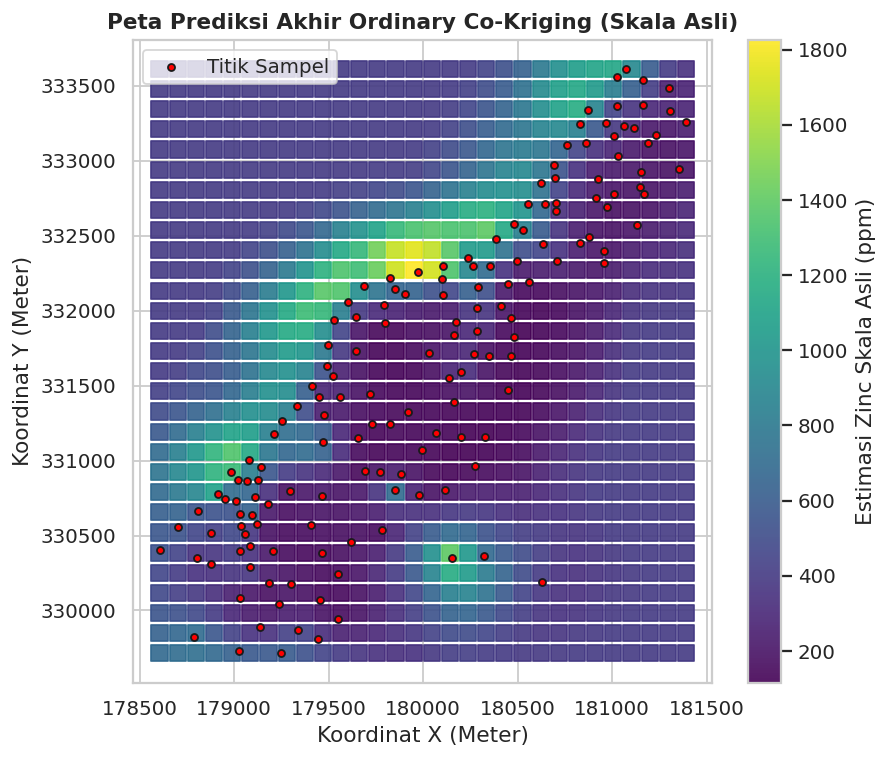

In [9]:
# ==============================================================================
# SCRIPT PYTHON LENGKAP: LMC & ORDINARY CO-KRIGING (ZINC & COPPER)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from scipy.stats import probplot
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pengaturan Tema Visualisasi Akademik
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 130

# ==============================================================================
# TAHAP 1: UPLOAD DATA & EKSPLORASI DATA AWAL (EDA)
# ==============================================================================
print("Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_meuse = pd.read_csv(filename).dropna(subset=['zinc', 'copper', 'lead', 'cadmium'])

print(f"\n[INFO] Total data valid dimuat: {len(df_meuse)} baris observasi.")

# Statistik Deskriptif
print("\n--- STATISTIK DESKRIPTIF SEMUA VARIABEL ---")
print(df_meuse[['zinc', 'copper', 'lead', 'cadmium']].describe())

# Transformasi Logaritma Natural untuk Mengatasi Kemencengan (Right-Skewed)
df_meuse['log_zinc'] = np.log(df_meuse['zinc'])
df_meuse['log_copper'] = np.log(df_meuse['copper'])

# Visualisasi EDA & Transformasi Log-Zinc & Log-Copper
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df_meuse['zinc'], kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Distribusi Asli Zinc (Primer)')
sns.histplot(df_meuse['log_zinc'], kde=True, ax=axes[0, 1], color='forestgreen')
axes[0, 1].set_title('Distribusi Log-Zinc (Normalisasi)')
sns.histplot(df_meuse['copper'], kde=True, ax=axes[1, 0], color='royalblue')
axes[1, 0].set_title('Distribusi Asli Copper (Sekunder)')
sns.histplot(df_meuse['log_copper'], kde=True, ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Distribusi Log-Copper (Normalisasi)')
plt.suptitle('Eksplorasi Data Awal & Transformasi Logaritma', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 2: PERHITUNGAN VARIOGRAM EMPIRIS & CROSS-VARIOGRAM
# ==============================================================================
coords = df_meuse[['x', 'y']].values
z1_log = df_meuse['log_zinc'].values       # Peubah Primer
z2_log = df_meuse['log_copper'].values   # Peubah Sekunder

def compute_coregionalization_variograms(coords, z1, z2, n_lags=12, max_dist=None):
    dist_matrix = squareform(pdist(coords))
    if max_dist is None: max_dist = np.max(dist_matrix) / 3.0

    dz1, dz2 = z1[:, None] - z1[None, :], z2[:, None] - z2[None, :]
    g11_mat = 0.5 * (dz1**2)
    g22_mat = 0.5 * (dz2**2)
    g12_mat = 0.5 * (dz1 * dz2)

    bins = np.linspace(0, max_dist, n_lags + 1)
    lags = 0.5 * (bins[:-1] + bins[1:])
    g11, g22, g12 = [], [], []

    for i in range(n_lags):
        mask = (dist_matrix >= bins[i]) & (dist_matrix < bins[i+1])
        if np.sum(mask) > 0:
            g11.append(np.mean(g11_mat[mask]))
            g22.append(np.mean(g22_mat[mask]))
            g12.append(np.mean(g12_mat[mask]))
        else:
            g11.append(np.nan); g22.append(np.nan); g12.append(np.nan)

    return lags, np.array(g11), np.array(g22), np.array(g12)

max_d = np.max(pdist(coords)) / 3.0
lags, g11_emp, g22_emp, g12_emp = compute_coregionalization_variograms(coords, z1_log, z2_log, max_dist=max_d)


# ==============================================================================
# TAHAP 3: FITTING MODEL TEORETIS LMC (EXPONENTIAL, SPHERICAL, GAUSSIAN)
# ==============================================================================
# Fungsi Model Teoretis
def model_func(h, a, m_type):
    h = np.asarray(h)
    if m_type == 'spherical':
        return np.where(h <= a, 1.5 * (h / a) - 0.5 * (h / a)**3, 1.0)
    elif m_type == 'exponential':
        return 1.0 - np.exp(-h / a)
    elif m_type == 'gaussian':
        return 1.0 - np.exp(-(h**2) / (a**2))

def fit_lmc(m_type):
    def loss(params):
        c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, a = params
        if (c12_0**2 > c11_0 * c22_0) or (c12_1**2 > c11_1 * c22_1) or (a <= 0): return 1e9

        g11_p = c11_0 + c11_1 * model_func(lags, a, m_type)
        g22_p = c22_0 + c22_1 * model_func(lags, a, m_type)
        g12_p = c12_0 + c12_1 * model_func(lags, a, m_type)

        valid = ~np.isnan(g11_emp)
        sse = np.sum((g11_emp[valid] - g11_p[valid])**2) + \
              np.sum((g22_emp[valid] - g22_p[valid])**2) + \
              np.sum((g12_emp[valid] - g12_p[valid])**2)
        return sse

    res = minimize(loss, [0.03, 0.03, 0.0, 0.5, 0.4, 0.1, max_d/2],
                   bounds=[(0,None),(0,None),(None,None),(0,None),(0,None),(None,None),(10,max_d)],
                   method='L-BFGS-B')
    return res.x, res.fun

# Fitting ketiga model
p_exp, sse_exp = fit_lmc('exponential')
p_sph, sse_sph = fit_lmc('spherical')
p_gau, sse_gau = fit_lmc('gaussian')

# Tabel Ringkasan Parameter Fitting LMC (Mirip Tugas 1)
df_lacking_table = pd.DataFrame({
    'Model LMC': ['Exponential', 'Spherical', 'Gaussian'],
    'Nugget Primer (c0)': [p_exp[0], p_sph[0], p_gau[0]],
    'Sill Total Primer (c0+c)': [p_exp[0]+p_exp[3], p_sph[0]+p_sph[3], p_gau[0]+p_gau[3]],
    'Range (a)': [p_exp[6], p_sph[6], p_gau[6]],
    'Nilai SSE': [sse_exp, sse_sph, sse_gau]
})

print("\n" + "="*80)
print(" TABEL 3.1: PARAMETER HASIL FITTING MODEL VARIOGRAM LMC")
print("="*80)
print(df_lacking_table.to_string(index=False))
print("="*80)

# Tentukan Model Terbaik berdasarkan SSE Terkecil
best_model_name = df_lacking_table.loc[df_lacking_table['Nilai SSE'].idxmin(), 'Model LMC']
print(f"\n[INFO] Model LMC terbaik terpilih berdasarkan SSE terkecil: {best_model_name}")

if best_model_name == 'Exponential':
    c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, range_lmc = p_exp
    m_type_sel = 'exponential'
elif best_model_name == 'Spherical':
    c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, range_lmc = p_sph
    m_type_sel = 'spherical'
else:
    c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, range_lmc = p_gau
    m_type_sel = 'gaussian'

# Visualisasi Perbandingan Model LMC
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
h_grid = np.linspace(0, max_d, 100)

for idx, (emp, title, c0, c1) in enumerate([
    (g11_emp, 'Auto-Variogram Log-Zinc', c11_0, c11_1),
    (g22_emp, 'Auto-Variogram Log-Copper', c22_0, c22_1),
    (g12_emp, 'Cross-Variogram (Zinc vs Copper)', c12_0, c12_1)
]):
    axes[idx].plot(lags, emp, 'ko', label='Empiris')
    axes[idx].plot(h_grid, c0 + c1 * model_func(h_grid, range_lmc, m_type_sel), 'r-', lw=2, label=f'Model {best_model_name}')
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Jarak Lag (h)')
    axes[idx].legend()

plt.suptitle(f'Linear Model of Coregionalization (LMC) Fitting - Terpilih: {best_model_name}', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 4 & 5: ORDINARY CO-KRIGING & VALIDASI SILANG (LOOCV)
# ==============================================================================
def get_cov(h, c0, c1, a, m_type):
    return (c0 + c1) - (c0 + c1 * model_func(h, a, m_type))

def ock_predict_single(s_coords, z1_s, z2_s, target_coord):
    n = len(s_coords)
    D = squareform(pdist(s_coords))
    C11 = get_cov(D, c11_0, c11_1, range_lmc, m_type_sel)
    C22 = get_cov(D, c22_0, c22_1, range_lmc, m_type_sel)
    C12 = get_cov(D, c12_0, c12_1, range_lmc, m_type_sel)

    K = np.zeros((2*n + 2, 2*n + 2))
    K[0:n, 0:n] = C11; K[0:n, n:2*n] = C12
    K[n:2*n, 0:n] = C12.T; K[n:2*n, n:2*n] = C22
    K[0:n, 2*n] = 1.0; K[2*n, 0:n] = 1.0
    K[n:2*n, 2*n+1] = 1.0; K[2*n+1, n:2*n] = 1.0

    dt = np.sqrt(np.sum((s_coords - target_coord)**2, axis=1))
    c11_t = get_cov(dt, c11_0, c11_1, range_lmc, m_type_sel)
    c12_t = get_cov(dt, c12_0, c12_1, range_lmc, m_type_sel)

    k0 = np.zeros(2*n + 2)
    k0[0:n] = c11_t; k0[n:2*n] = c12_t; k0[2*n] = 1.0; k0[2*n+1] = 0.0

    weights = np.linalg.solve(K + np.eye(2*n+2)*1e-5, k0)
    log_pred = np.sum(weights[0:n] * z1_s) + np.sum(weights[n:2*n] * z2_s)
    variance = np.sum(weights * k0)
    return np.exp(log_pred), variance

print("\n[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV) Co-Kriging...")
y_true = df_meuse['zinc'].values
y_true_log = df_meuse['log_zinc'].values
y_pred_log = []

for i in range(len(coords)):
    mask = np.ones(len(coords), dtype=bool)
    mask[i] = False
    p_val, _ = ock_predict_single(coords[mask], z1_log[mask], z2_log[mask], coords[i])
    y_pred_log.append(np.log(p_val))

y_pred_log = np.array(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
mae = mean_absolute_error(y_true_log, y_pred_log)
r2 = r2_score(y_true_log, y_pred_log)

print("\n" + "="*55)
print(" HASIL EVALUASI VALIDASI SILANG ORDINARY CO-KRIGING")
print("="*55)
print(f" RMSE (Skala Log) : {rmse:.4f}")
print(f" MAE (Skala Log)  : {mae:.4f}")
print(f" Koefisien (R²)   : {r2:.4f}")
print("="*55)

# Visualisasi Scatter Plot Validasi Silang
plt.figure(figsize=(6, 6))
plt.scatter(y_true_log, y_pred_log, color='purple', alpha=0.7, edgecolors='k')
plt.plot([y_true_log.min(), y_true_log.max()], [y_true_log.min(), y_true_log.max()], 'r--', lw=2, label='Garis Ideal 1:1')
plt.title(f'Validasi Silang Co-Kriging (RMSE={rmse:.3f}, R²={r2:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('Observasi Log-Zinc')
plt.ylabel('Prediksi Log-Zinc')
plt.legend()
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 6: PEMBUATAN PETA PREDIKSI SPASIAL & BACK-TRANSFORMATION
# ==============================================================================
print("\n[INFO] Membangun Grid Peta Interpolasi Spasial Co-Kriging...")
grid_x = np.linspace(df_meuse['x'].min(), df_meuse['x'].max(), 30)
grid_y = np.linspace(df_meuse['y'].min(), df_meuse['y'].max(), 30)
GX, GY = np.meshgrid(grid_x, grid_y)
G_coords = np.c_[GX.ravel(), GY.ravel()]

preds_original, variances = [], []
for pt in G_coords:
    p_orig, var = ock_predict_single(coords, z1_log, z2_log, pt)
    preds_original.append(p_orig)
    variances.append(var)

preds_original = np.array(preds_original)

print(f"\nRingkasan Hasil Prediksi Skala Asli Zinc:")
print(f"- Minimum : {preds_original.min():.2f}")
print(f"- Maksimum: {preds_original.max():.2f}")
print(f"- Rata-rata: {preds_original.mean():.2f}")

# Visualisasi Peta Hasil Prediksi Co-Kriging Skala Asli
plt.figure(figsize=(7, 6))
plt.scatter(G_coords[:, 0], G_coords[:, 1], c=preds_original, cmap='viridis', s=80, marker='s', alpha=0.9)
plt.colorbar(label='Estimasi Zinc Skala Asli (ppm)')
plt.scatter(df_meuse['x'], df_meuse['y'], c='red', s=15, edgecolors='k', label='Titik Sampel')
plt.title('Peta Prediksi Akhir Ordinary Co-Kriging (Skala Asli)', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.legend()
plt.tight_layout()
plt.show()